# Step 1: Load Source Data
Load the two raw CSV files and confirm the dataset shape before any transformations.

In [2]:
raw_data_path <- "data/raw/diabetic_data.csv"
ids_map_path <- "data/raw/IDS_mapping.csv"

diabetic <- read.csv(
  raw_data_path,
  stringsAsFactors = FALSE,
  na.strings = c("", "?", "NULL")
)

ids_raw <- read.csv(
  ids_map_path,
  header = FALSE,
  stringsAsFactors = FALSE,
  fill = TRUE,
  na.strings = c("", "NULL")
)

colnames(ids_raw) <- c("key", "description")

cat("diabetic_data.csv shape:", sprintf("(%d, %d)", nrow(diabetic), ncol(diabetic)), "\n")
cat("IDS_mapping raw shape:", sprintf("(%d, %d)", nrow(ids_raw), ncol(ids_raw)), "\n\n")

old_width <- getOption("width")
options(width = 1000)

cat("diabetic_data preview (all columns):\n")
print(head(diabetic))

options(width = old_width)



diabetic_data.csv shape: (101766, 50) 
IDS_mapping raw shape: (68, 2) 

diabetic_data preview (all columns):
  encounter_id patient_nbr            race gender     age weight admission_type_id discharge_disposition_id admission_source_id time_in_hospital payer_code        medical_specialty num_lab_procedures num_procedures num_medications number_outpatient number_emergency number_inpatient diag_1 diag_2 diag_3 number_diagnoses max_glu_serum A1Cresult metformin repaglinide nateglinide chlorpropamide glimepiride acetohexamide glipizide glyburide tolbutamide pioglitazone rosiglitazone acarbose miglitol troglitazone tolazamide examide citoglipton insulin glyburide.metformin glipizide.metformin glimepiride.pioglitazone metformin.rosiglitazone metformin.pioglitazone change diabetesMed readmitted
1      2278392     8222157       Caucasian Female  [0-10)   <NA>                 6                       25                   1                1       <NA> Pediatrics-Endocrinology                 41 

# Step 2: Parse IDS Mapping Tables
Split IDS_mapping.csv into three mapping tables: admission type, discharge disposition, and admission source.

In [3]:
header_rows <- which(grepl("_id$", ids_raw$key) & ids_raw$description == "description")

extract_mapping <- function(section_name) {
  start_idx <- which(ids_raw$key == section_name & ids_raw$description == "description")
  if (length(start_idx) == 0) return(data.frame(id = integer(), description = character()))
  start_idx <- start_idx[1]

  next_headers <- header_rows[header_rows > start_idx]
  end_idx <- if (length(next_headers) > 0) next_headers[1] - 1 else nrow(ids_raw)

  out <- ids_raw[(start_idx + 1):end_idx, , drop = FALSE]
  out <- out[!is.na(out$key) & nzchar(trimws(out$key)), , drop = FALSE]
  out$id <- suppressWarnings(as.integer(out$key))
  out <- out[!is.na(out$id), c("id", "description"), drop = FALSE]
  rownames(out) <- NULL
  out
}

admission_type_map <- extract_mapping("admission_type_id")
discharge_disposition_map <- extract_mapping("discharge_disposition_id")
admission_source_map <- extract_mapping("admission_source_id")

cat("admission_type_map preview:\n")
print(head(admission_type_map, 5))

cat("\ndischarge_disposition_map preview:\n")
print(head(discharge_disposition_map, 5))

cat("\nadmission_source_map preview:\n")
print(head(admission_source_map, 5))

admission_type_map preview:
  id   description
1  1     Emergency
2  2        Urgent
3  3      Elective
4  4       Newborn
5  5 Not Available

discharge_disposition_map preview:
  id                                                          description
1  1                                                   Discharged to home
2  2                Discharged/transferred to another short term hospital
3  3                                        Discharged/transferred to SNF
4  4                                        Discharged/transferred to ICF
5  5 Discharged/transferred to another type of inpatient care institution

admission_source_map preview:
  id                                     description
1  1                              Physician Referral
2  2                                 Clinic Referral
3  3                                    HMO Referral
4  4                        Transfer from a hospital
5  5  Transfer from a Skilled Nursing Facility (SNF)


# Step 3: Data Cleaning

In [4]:
# Patient-level deduplication: Keep only the first encounter for each patient_nbr
rows_before <- nrow(diabetic)

encounter_num <- suppressWarnings(as.numeric(diabetic$encounter_id))
order_idx <- order(diabetic$patient_nbr, encounter_num, na.last = TRUE)
diabetic <- diabetic[order_idx, , drop = FALSE]
diabetic <- diabetic[!duplicated(diabetic$patient_nbr), , drop = FALSE]

rows_after <- nrow(diabetic)
cat("Patient-level deduplication complete (first encounter per patient_nbr kept).\n")
cat("Rows before:", rows_before, "| Rows after:", rows_after, "\n")

Patient-level deduplication complete (first encounter per patient_nbr kept).
Rows before: 101766 | Rows after: 71518 


In [5]:
# Drop columns with high missingness or low relevance
columns_to_drop <- c("weight", "medical_specialty", "payer_code")

dropped_columns <- c()
for (col_name in columns_to_drop) {
  if (col_name %in% names(diabetic)) {
    diabetic <- diabetic[, names(diabetic) != col_name, drop = FALSE]
    dropped_columns <- c(dropped_columns, col_name)
  }
}

if (length(dropped_columns) > 0) {
  cat("Dropped columns:", paste(dropped_columns, collapse = ", "), "\n")
} else {
  cat("No target columns were present to drop.\n")
}

already_absent <- setdiff(columns_to_drop, dropped_columns)
if (length(already_absent) > 0) {
  cat("Already absent:", paste(already_absent, collapse = ", "), "\n")
}

cat("Updated diabetic_data shape:", sprintf("(%d, %d)", nrow(diabetic), ncol(diabetic)), "\n")

Dropped columns: weight, medical_specialty, payer_code 
Updated diabetic_data shape: (71518, 47) 


In [6]:
# Impute missing
if ("race" %in% names(diabetic)) {
  na_before <- sum(is.na(diabetic$race))
  diabetic$race[is.na(diabetic$race)] <- "Other"
  na_after <- sum(is.na(diabetic$race))

  cat("Filled", na_before, "missing values in race with 'Other'.\n")
  cat("Remaining missing values in race:", na_after, "\n")
} else {
  cat("Column 'race' not found; no imputation applied.\n")
}

for (lab_col in c("max_glu_serum", "A1Cresult")) {
  if (lab_col %in% names(diabetic)) {
    na_before <- sum(is.na(diabetic[[lab_col]]))
    diabetic[[lab_col]][is.na(diabetic[[lab_col]])] <- "None"
    cat("Filled", na_before, "missing values in", lab_col, "with 'None'.\n")
  }
}

Filled 1948 missing values in race with 'Other'.
Remaining missing values in race: 0 
Filled 0 missing values in max_glu_serum with 'None'.
Filled 0 missing values in A1Cresult with 'None'.


In [7]:
# Drop rows with invalid or missing critical values
if ("gender" %in% names(diabetic)) {
  invalid_mask <- trimws(as.character(diabetic$gender)) == "Unknown/Invalid"
  invalid_mask[is.na(invalid_mask)] <- FALSE

  invalid_count <- sum(invalid_mask)
  diabetic <- diabetic[!invalid_mask, , drop = FALSE]

  cat("Dropped", invalid_count, "rows where gender == 'Unknown/Invalid'.\n")
} else {
  cat("Column 'gender' not found; no rows dropped.\n")
}

if ("diag_1" %in% names(diabetic)) {
  diag1_missing <- is.na(diabetic$diag_1) | trimws(as.character(diabetic$diag_1)) %in% c("", "?")
  diag1_drop_count <- sum(diag1_missing)
  diabetic <- diabetic[!diag1_missing, , drop = FALSE]
  cat("Dropped", diag1_drop_count, "rows with missing diag_1.\n")
} else {
  cat("Column 'diag_1' not found; no rows dropped for primary diagnosis.\n")
}

cat("Updated row count after row-level cleaning:", nrow(diabetic), "\n")

Dropped 3 rows where gender == 'Unknown/Invalid'.
Dropped 11 rows with missing diag_1.
Updated row count after row-level cleaning: 71504 


In [8]:
# Map diagnosis codes to categories
map_diag_category <- function(code, allow_none = FALSE) {
  code_chr <- toupper(trimws(as.character(code)))

  if (is.na(code) || code_chr == "" || code_chr == "?") {
    return(if (allow_none) "None" else NA_character_)
  }

  if (grepl("^[VE]", code_chr)) {
    return("Other")
  }

  code_num <- suppressWarnings(as.numeric(code_chr))
  if (is.na(code_num)) {
    return("Other")
  }

  if ((code_num >= 390 && code_num <= 459) || code_num == 785) return("Circulatory")
  if ((code_num >= 460 && code_num <= 519) || code_num == 786) return("Respiratory")
  if ((code_num >= 520 && code_num <= 579) || code_num == 787) return("Digestive")
  if (code_num >= 250 && code_num < 251) return("Diabetes")
  if (code_num >= 800 && code_num <= 999) return("Injury")
  if (code_num >= 710 && code_num <= 739) return("Musculoskeletal")
  if ((code_num >= 580 && code_num <= 629) || code_num == 788) return("Genitourinary")
  if (code_num >= 140 && code_num <= 239) return("Neoplasms")

  return("Other")
}

diabetic$diag_1 <- vapply(diabetic$diag_1, function(x) map_diag_category(x, allow_none = FALSE), character(1))
diabetic$diag_2 <- vapply(diabetic$diag_2, function(x) map_diag_category(x, allow_none = TRUE), character(1))
diabetic$diag_3 <- vapply(diabetic$diag_3, function(x) map_diag_category(x, allow_none = TRUE), character(1))

diag1_post_map_missing <- is.na(diabetic$diag_1)
if (any(diag1_post_map_missing)) {
  diabetic <- diabetic[!diag1_post_map_missing, , drop = FALSE]
  cat("Dropped", sum(diag1_post_map_missing), "additional rows with missing diag_1 after mapping.\n")
}

cat("diag_1 category counts (top 10):\n")
print(head(sort(table(diabetic$diag_1), decreasing = TRUE), 10))

cat("\ndiag_2 category counts (top 10):\n")
print(head(sort(table(diabetic$diag_2), decreasing = TRUE), 10))

cat("\ndiag_3 category counts (top 10):\n")
print(head(sort(table(diabetic$diag_3), decreasing = TRUE), 10))

diag_1 category counts (top 10):

    Circulatory           Other     Respiratory       Digestive        Diabetes 
          21893           12347            9776            6570            5805 
         Injury Musculoskeletal   Genitourinary       Neoplasms 
           4777            4080            3514            2742 

diag_2 category counts (top 10):

    Circulatory           Other        Diabetes     Respiratory   Genitourinary 
          22532           18404            9756            7242            5467 
      Digestive          Injury       Neoplasms Musculoskeletal            None 
           2907            1856            1750            1297             293 

diag_3 category counts (top 10):

    Circulatory           Other        Diabetes     Respiratory   Genitourinary 
          21308           20416           12659            4872            4198 
      Digestive          Injury Musculoskeletal       Neoplasms            None 
           2746            1441      

In [9]:
# Map ID columns to descriptive labels
map_id_to_label <- function(df, id_col, mapping_df) {
  if (!(id_col %in% names(df))) return(df[[id_col]])
  lookup <- setNames(mapping_df$description, as.character(mapping_df$id))
  out <- lookup[as.character(df[[id_col]])]
  out[is.na(out)] <- "Unknown"
  unname(out)
}

if (exists("admission_type_map") && exists("discharge_disposition_map") && exists("admission_source_map")) {
  diabetic$admission_type_id <- map_id_to_label(diabetic, "admission_type_id", admission_type_map)
  diabetic$discharge_disposition_id <- map_id_to_label(diabetic, "discharge_disposition_id", discharge_disposition_map)
  diabetic$admission_source_id <- map_id_to_label(diabetic, "admission_source_id", admission_source_map)

  cat("Mapped admission/discharge/source ID columns to descriptive labels.\n")
} else {
  cat("Mapping tables not found; run Step 2 first.\n")
}

Mapped admission/discharge/source ID columns to descriptive labels.


In [10]:
# Create binary target variable for readmission within 30 days and drop original target label
if ("readmitted" %in% names(diabetic)) {
  diabetic$readmitted_binary <- ifelse(diabetic$readmitted == "<30", 1L, 0L)
  diabetic$readmitted <- NULL

  cat("Created readmitted_binary: 1 for <30, 0 for >30 or NO.\n")
  cat("Dropped original 'readmitted' column to avoid target confusion.\n")
  cat("Class balance (readmitted_binary):\n")
  print(table(diabetic$readmitted_binary))
} else if ("readmitted_binary" %in% names(diabetic)) {
  cat("Column 'readmitted' already removed. Using existing readmitted_binary.\n")
  cat("Class balance (readmitted_binary):\n")
  print(table(diabetic$readmitted_binary))
} else {
  cat("Neither 'readmitted' nor 'readmitted_binary' found.\n")
}

Created readmitted_binary: 1 for <30, 0 for >30 or NO.
Dropped original 'readmitted' column to avoid target confusion.
Class balance (readmitted_binary):

    0     1 
65213  6291 


In [11]:
# Save the cleaned dataset
output_dir <- "data/processed"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

rds_path <- file.path(output_dir, "diabetic_cleaned.rds")
saveRDS(diabetic, rds_path)

cat("Saved cleaned dataset to:", rds_path, "\n")
cat("Saved data shape:", sprintf("(%d, %d)", nrow(diabetic), ncol(diabetic)), "\n")

Saved cleaned dataset to: data/processed/diabetic_cleaned.rds 
Saved data shape: (71504, 47) 


# Step 4: Exploratory Data Analysis
Load the cleaned RDS file and prepare column-level distribution summaries for exploratory data analysis.

In [12]:
# Load the cleaned dataset for analysis
rds_input_path <- "data/processed/diabetic_cleaned.rds"
if (!file.exists(rds_input_path)) {
  stop("Cleaned RDS not found. Run the save step first.")
}

analysis_df <- readRDS(rds_input_path)

cat("Loaded cleaned dataset from:", rds_input_path, "\n")
cat("analysis_df shape:", sprintf("(%d, %d)", nrow(analysis_df), ncol(analysis_df)), "\n")

cat("\nFirst 6 rows preview:\n")
print(head(analysis_df))

Loaded cleaned dataset from: data/processed/diabetic_cleaned.rds 
analysis_df shape: (71504, 47) 

First 6 rows preview:
      encounter_id patient_nbr            race gender     age admission_type_id
4268      24437208         135       Caucasian Female [50-60)            Urgent
5828      29758806         378       Caucasian Female [50-60)          Elective
67609    189899286         729       Caucasian Female [80-90)         Emergency
17495     64331490         774       Caucasian Female [80-90)         Emergency
2271      14824206         927 AfricanAmerican Female [30-40)         Emergency
1165       8380170        1152 AfricanAmerican Female [50-60)         Emergency
           discharge_disposition_id admission_source_id time_in_hospital
4268             Discharged to home  Physician Referral                8
5828             Discharged to home  Physician Referral                2
67609 Discharged/transferred to SNF      Emergency Room                4
17495            Discharged

In [13]:
# Identify categorical and numeric variables for EDA
library(dplyr)
library(tidyr)
library(ggplot2)
library(corrplot)


analysis_df <- analysis_df %>%
  mutate(readmitted_binary = factor(readmitted_binary, levels = c(0, 1), labels = c("No (<30=0)", "Yes (<30=1)")))

medication_cols <- intersect(
  c(
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide.metformin",
    "glipizide.metformin", "glimepiride.pioglitazone", "metformin.rosiglitazone",
    "metformin.pioglitazone", "diabetesMed"
  ),
  names(analysis_df)
 )

eda_categorical_vars <- intersect(
  c("race", "age", "diag_1", "diag_2", "diag_3", medication_cols),
  names(analysis_df)
 )

eda_numeric_vars <- setdiff(names(analysis_df)[sapply(analysis_df, is.numeric)], c("encounter_id", "patient_nbr"))

cat("Categorical vars used for faceted bar grid:", length(eda_categorical_vars), "\n")
cat("Numeric vars used for faceted distribution grid:", length(eda_numeric_vars), "\n")

Warning message:
"package 'corrplot' was built under R version 4.4.3"
corrplot 0.95 loaded



Categorical vars used for faceted bar grid: 29 
Numeric vars used for faceted distribution grid: 8 


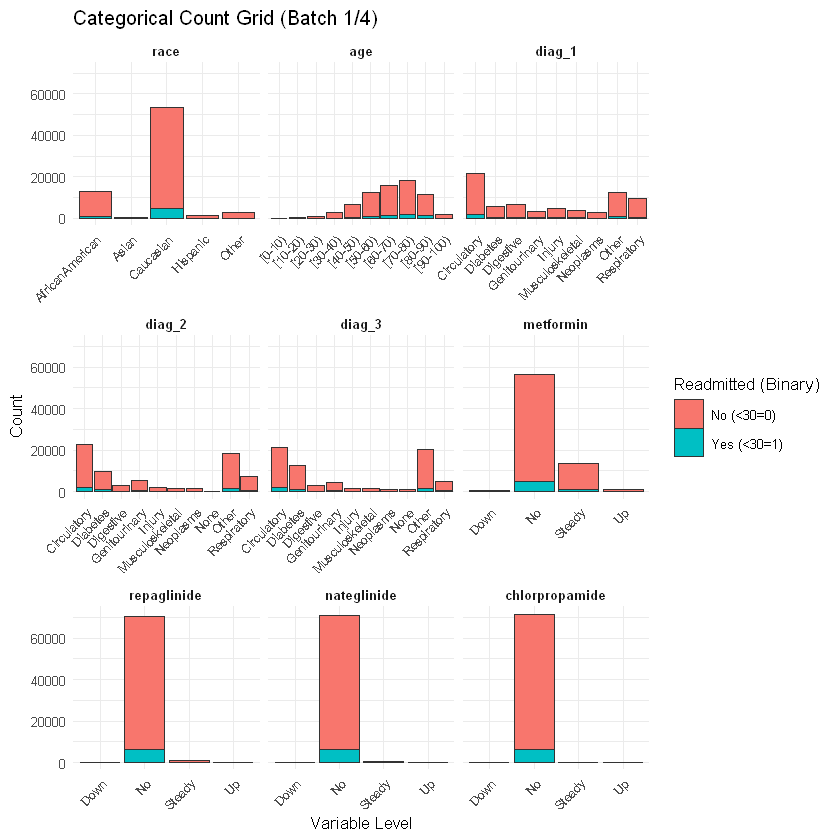

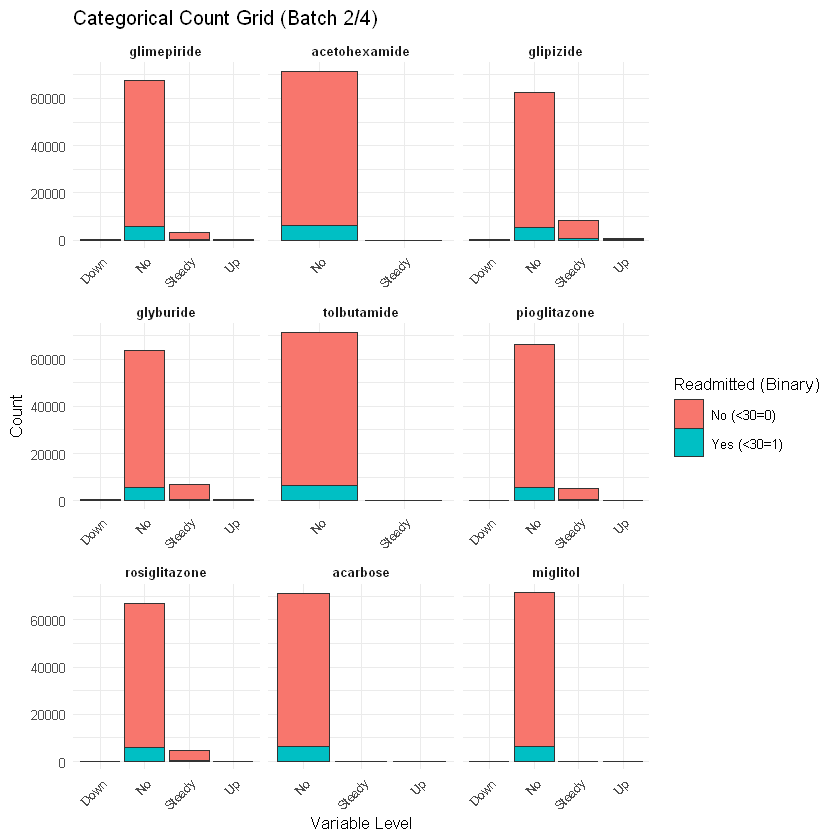

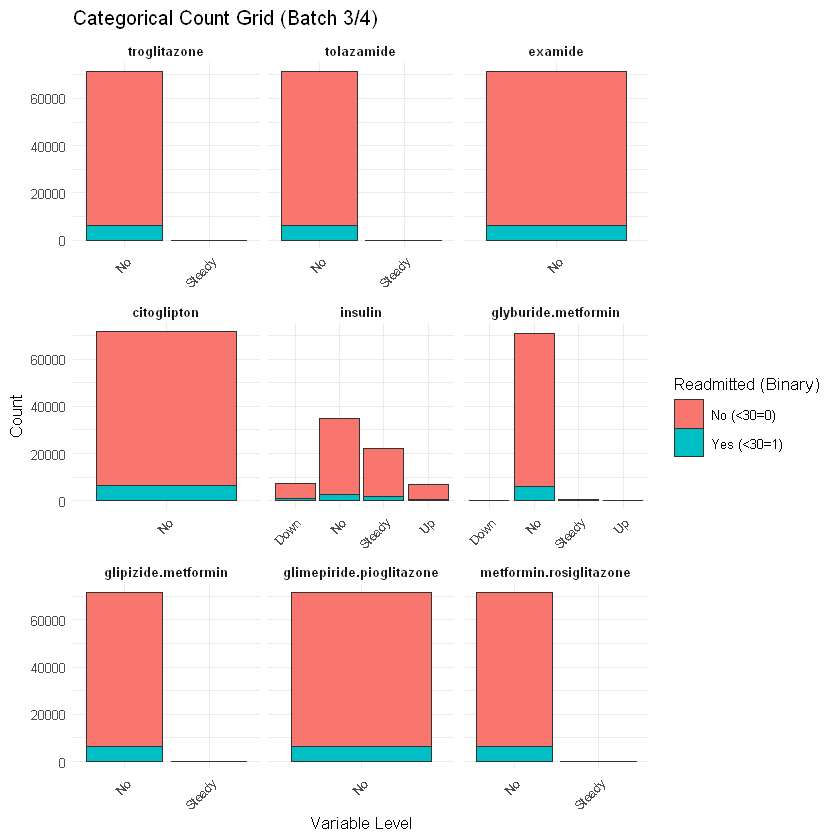

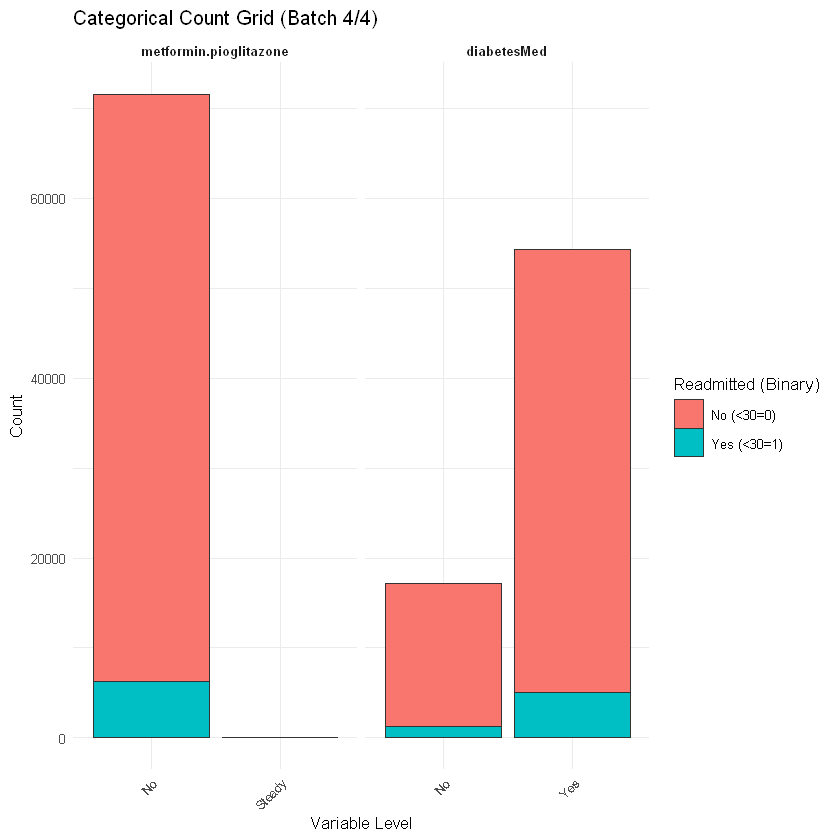

In [14]:
# Regular count bar charts for categorical variables (batched), colored by readmission class
medication_cols_plot <- intersect(
  c(
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide.metformin",
    "glipizide.metformin", "glimepiride.pioglitazone", "metformin.rosiglitazone",
    "metformin.pioglitazone", "diabetesMed"
  ),
  names(analysis_df)
)

categorical_vars_plot <- intersect(
  c("race", "age", "diag_1", "diag_2", "diag_3", medication_cols_plot),
  names(analysis_df)
)

plot_df <- analysis_df
readmit_chr <- trimws(as.character(plot_df$readmitted_binary))
readmit_num <- ifelse(
  readmit_chr %in% c("1", "Yes (<30=1)", "Yes"), 1L,
  ifelse(readmit_chr %in% c("0", "No (<30=0)", "No"), 0L, NA_integer_)
 )
plot_df$readmitted_plot <- factor(readmit_num, levels = c(0, 1), labels = c("No (<30=0)", "Yes (<30=1)"))

batch_size <- 9
var_batches <- split(categorical_vars_plot, ceiling(seq_along(categorical_vars_plot) / batch_size))

for (i in seq_along(var_batches)) {
  batch_vars <- var_batches[[i]]

  categorical_long <- plot_df %>%
    select(all_of(batch_vars), readmitted_plot) %>%
    pivot_longer(cols = -readmitted_plot, names_to = "variable", values_to = "level") %>%
    mutate(
      level = as.character(level),
      level = ifelse(is.na(level), "Missing", level),
      variable = factor(variable, levels = batch_vars)
    )

  p <- ggplot(categorical_long, aes(x = level, fill = readmitted_plot)) +
    geom_bar(position = "stack", color = "grey20", linewidth = 0.1) +
    facet_wrap(~ variable, scales = "free_x", ncol = 3) +
    labs(
      title = paste0("Categorical Count Grid (Batch ", i, "/", length(var_batches), ")"),
      x = "Variable Level",
      y = "Count",
      fill = "Readmitted (Binary)"
    ) +
    theme_minimal(base_size = 10) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 7),
      strip.text = element_text(face = "bold")
    )

  print(p)
}

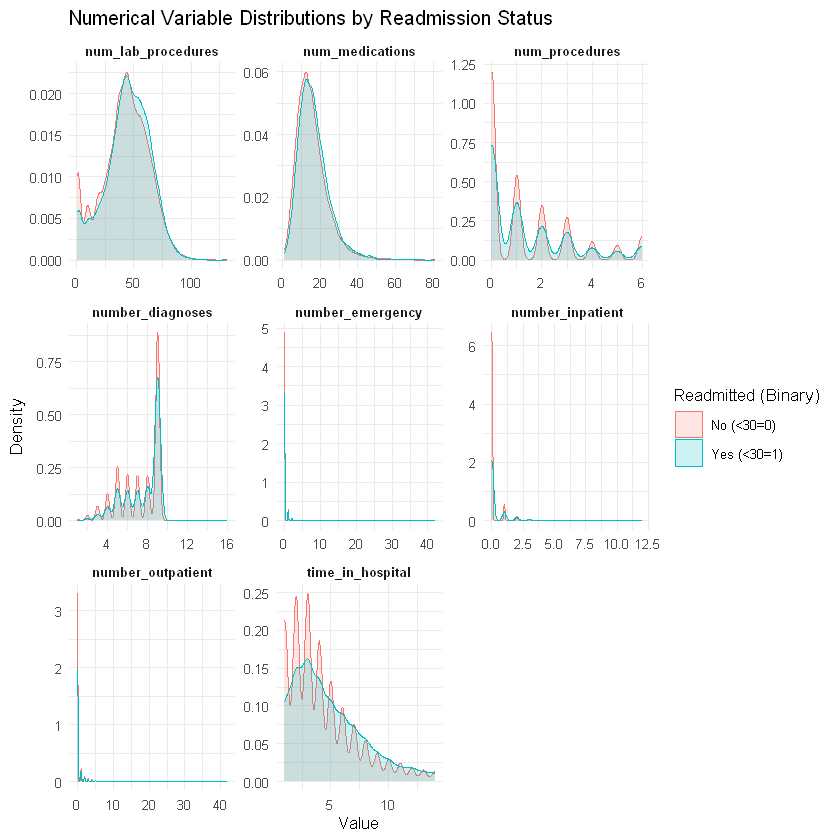

In [15]:
numeric_long <- analysis_df %>%
  select(all_of(eda_numeric_vars), readmitted_binary) %>%
  pivot_longer(cols = -readmitted_binary, names_to = "variable", values_to = "value")

ggplot(numeric_long, aes(x = value, color = readmitted_binary, fill = readmitted_binary)) +
  geom_density(alpha = 0.20, na.rm = TRUE) +
  facet_wrap(~ variable, scales = "free", ncol = 3) +
  labs(
    title = "Numerical Variable Distributions by Readmission Status",
    x = "Value",
    y = "Density",
    color = "Readmitted (Binary)",
    fill = "Readmitted (Binary)"
  ) +
  theme_minimal(base_size = 10) +
  theme(strip.text = element_text(face = "bold"))

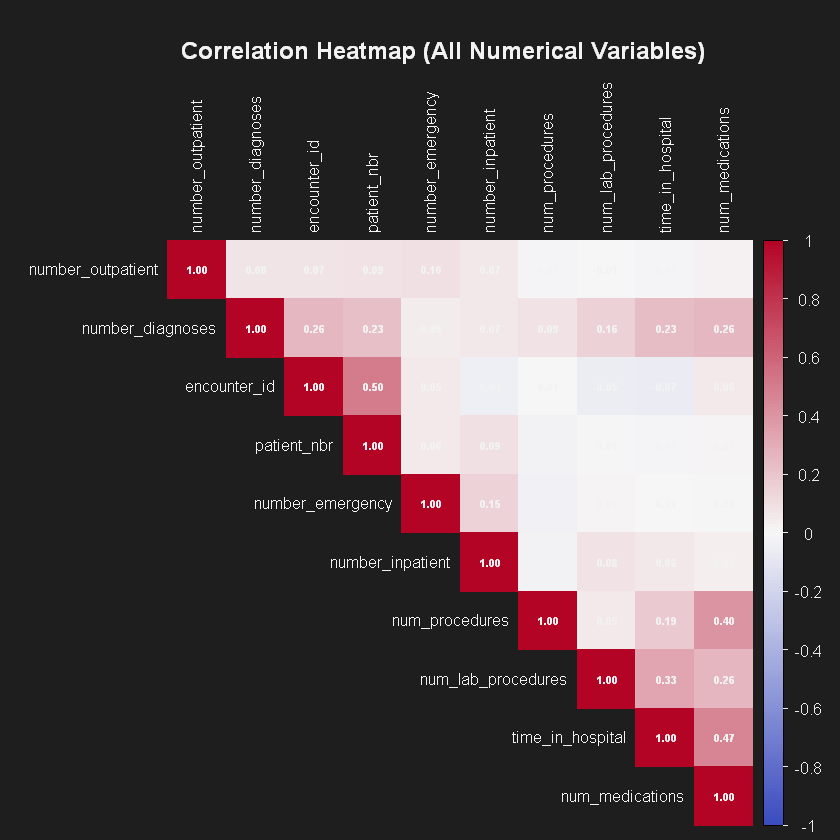

In [16]:
correlation_vars <- names(analysis_df)[sapply(analysis_df, is.numeric)]
correlation_matrix <- cor(analysis_df[correlation_vars], use = "pairwise.complete.obs")

# Dark-mode-friendly corrplot styling
op <- par(no.readonly = TRUE)
par(bg = "#1E1E1E", fg = "#EAEAEA")

corr_cols <- colorRampPalette(c("#3B4CC0", "#F7F7F7", "#B40426"))(200)

corrplot(
  correlation_matrix,
  method = "color",
  type = "upper",
  order = "hclust",
  col = corr_cols,
  addCoef.col = "#F2F2F2",
  number.cex = 0.55,
  tl.cex = 0.8,
  tl.col = "#F2F2F2",
  cl.cex = 0.8,
  mar = c(0, 0, 3, 0)
 )

title("Correlation Heatmap (All Numerical Variables)", col.main = "#F2F2F2")
par(op)

## Step 5: Linear Models
In this section we explore linear models including lasso and ridge logistic regressions, General Additive Models (GAM)

### Data Splitting and One-hot Encoding

In [ ]:
# 1. Package Management
if (!require("pacman")) install.packages("pacman")
pacman::p_load(tidyverse, tidymodels, rsample, recipes, parsnip)

# 2. Initial Split: Separate into train_data and test_data (80/20)
set.seed(5740)
data_split <- initial_split(
  analysis_df,
  prop = 0.80,
  strata = readmitted_binary
)

train_data <- training(data_split)
test_data  <- testing(data_split)

# 3. Define Recipe: Create the blueprint (encoding, scaling, etc.)
diabetes_recipe <- recipe(readmitted_binary ~ ., data = train_data) %>%
  step_novel(all_nominal_predictors()) %>%
  step_dummy(all_nominal_predictors(), one_hot = TRUE) %>%
  step_zv(all_predictors()) %>%
  step_normalize(all_numeric_predictors())

# 4. Prep: Learn the parameters (means, levels, etc.) from train_data only
diabetes_prep <- prep(diabetes_recipe, training = train_data)

# 5. Bake: Apply those learned parameters to both train_data and test_data
train_encoded <- bake(diabetes_prep, new_data = train_data)
test_encoded  <- bake(diabetes_prep, new_data = test_data)

# 6. Output train/test shapes and all column names
cat("Train shape:", dim(train_encoded)[1], "rows x", dim(train_encoded)[2], "columns\n")
cat("Test shape:", dim(test_encoded)[1], "rows x", dim(test_encoded)[2], "columns\n\n")

cat("columns:\n")
print(names(train_encoded))


Train shape: 57203 rows x 183 columns
Test shape: 14301 rows x 183 columns

columns:
  [1] "encounter_id"                                                                                                                      
  [2] "patient_nbr"                                                                                                                       
  [3] "time_in_hospital"                                                                                                                  
  [4] "num_lab_procedures"                                                                                                                
  [5] "num_procedures"                                                                                                                    
  [6] "num_medications"                                                                                                                   
  [7] "number_outpatient"                                                        